# Итерация 3 — Смесь локальных и глобальной моделей

Цель:
Проверить, сохраняется ли зависимость скорости сходимости ADMM
от формы записи задачи (shared-variable vs coupled constraints)
на новой ML-постановке.

Рассматриваем задачу:
Mixture of Local and Global Models.


## 1. Исходная ML-постановка

Рассматриваем N агентов.

У каждого агента i есть локальные данные (X_i, y_i).

Каждый агент обучает:
- локальную модель w_i
- при наличии общей глобальной модели w_0

Целевая функция имеет вид:

    sum_i f_i(w_i, w_0)

где присутствует регуляризация,
связывающая локальные и глобальную компоненты.


### 1.1 Конкретная постановка задачи

Пусть имеется $N$ агентов.

У агента $i$ имеются данные:
$$
X_i \in \mathbb{R}^{n_i \times d}, 
\qquad
y_i \in \mathbb{R}^{n_i}.
$$

Каждый агент обучает локальный параметр
$$
w_i \in \mathbb{R}^d.
$$

Также вводится глобальная модель
$$
w_0 \in \mathbb{R}^d.
$$

Рассматриваем задачу линейной регрессии со смешанной регуляризацией:

$$
\min_{w_0, \{w_i\}}
\;
\sum_{i=1}^N
\left[
\frac{1}{2 n_i}
\|X_i w_i - y_i\|^2
+
\frac{\lambda}{2}
\|w_i - w_0\|^2
\right]
+
\frac{\gamma}{2}
\|w_0\|^2.
$$

Здесь:

- $\lambda \ge 0$ — сила согласования локальных и глобальной моделей;
- $\gamma \ge 0$ — регуляризация глобальной модели.


## 2. Приведение к задаче вида (P)

Переписываем задачу в форме:

    min sum_i f_i(x_i)
    при ограничении A x = b

Необходимо явно выделить:

- локальные переменные
- глобальные переменные
- аффинные связующие ограничения
- структуру матрицы A


### 2.1 Переписывание задачи в аффинной форме

Исходная задача:

$$
\min_{w_0, \{w_i\}}
\;
\sum_{i=1}^N
\left[
\frac{1}{2 n_i}
\|X_i w_i - y_i\|^2
+
\frac{\lambda}{2}
\|w_i - w_0\|^2
\right]
+
\frac{\gamma}{2}
\|w_0\|^2.
$$

Чтобы привести задачу к форме (P), 
вынесем согласование в ограничения.

Введём явные аффинные ограничения:

$$
w_i - w_0 = 0,
\qquad i = 1, \dots, N.
$$

Тогда задачу можно переписать как

$$
\min_{w_0, \{w_i\}}
\;
\sum_{i=1}^N
\frac{1}{2 n_i}
\|X_i w_i - y_i\|^2
+
\frac{\gamma}{2}
\|w_0\|^2
$$

при ограничениях

$$
w_i - w_0 = 0,
\qquad i = 1, \dots, N.
$$


### 2.2 Явная форма задачи (P)

Соберём все переменные в один вектор:

$$
x =
\begin{bmatrix}
w_1 \\
\vdots \\
w_N \\
w_0
\end{bmatrix}
\in \mathbb{R}^{(N+1)d}.
$$

Целевая функция раскладывается в сумму:

$$
\sum_{i=1}^N f_i(w_i) + g(w_0),
$$

где

$$
f_i(w_i) = \frac{1}{2 n_i}\|X_i w_i - y_i\|^2,
$$

$$
g(w_0) = \frac{\gamma}{2}\|w_0\|^2.
$$

Аффинные ограничения имеют вид:

$$
w_i - w_0 = 0,
\qquad i = 1, \dots, N.
$$

В матричной форме:

$$
A x = 0,
$$

где матрица $A$ имеет блочную структуру:

- в строке, соответствующей агенту $i$,
  стоит блок $I_d$ в позиции $w_i$,
- и блок $-I_d$ в позиции $w_0$,
- остальные блоки равны нулю.


## 3. Формулировка с общей переменной (Shared-Variable)

Вводим глобальную переменную w_0
и локальные копии w_i.

Ограничения:

    w_i = w_0  для всех i

Далее выводим шаги ADMM.


### 3.1 Расширенный лагранжиан

Задача:

$$
\min_{w_0, \{w_i\}}
\;
\sum_{i=1}^N
\frac{1}{2 n_i}
\|X_i w_i - y_i\|^2
+
\frac{\gamma}{2}
\|w_0\|^2
$$

при ограничениях

$$
w_i - w_0 = 0.
$$

Введём двойственные переменные $u_i$.

Расширенный лагранжиан:

$$
\mathcal{L}_\rho =
\sum_{i=1}^N
\frac{1}{2 n_i}
\|X_i w_i - y_i\|^2
+
\frac{\gamma}{2}
\|w_0\|^2
+
\sum_{i=1}^N
u_i^\top (w_i - w_0)
+
\frac{\rho}{2}
\sum_{i=1}^N
\|w_i - w_0\|^2.
$$


### 3.2 Шаги ADMM

Итерации ADMM имеют вид:

1️⃣ Обновление локальных моделей $w_i$:

$$
w_i^{k+1}
=
\arg\min_{w_i}
\left(
\frac{1}{2 n_i}\|X_i w_i - y_i\|^2
+
u_i^{k\top}(w_i - w_0^k)
+
\frac{\rho}{2}\|w_i - w_0^k\|^2
\right).
$$

Это квадратичная задача, имеющая аналитическое решение:

$$
\left(
\frac{1}{n_i} X_i^\top X_i + \rho I
\right)
w_i
=
\frac{1}{n_i} X_i^\top y_i
+
\rho w_0^k
-
u_i^k.
$$

---

2️⃣ Обновление глобальной модели $w_0$:

$$
w_0^{k+1}
=
\arg\min_{w_0}
\left(
\frac{\gamma}{2}\|w_0\|^2
-
\sum_{i=1}^N u_i^{k\top} w_0
+
\frac{\rho}{2}
\sum_{i=1}^N
\|w_i^{k+1} - w_0\|^2
\right).
$$

Решение:

$$
(\gamma + \rho N) w_0
=
\rho \sum_{i=1}^N w_i^{k+1}
+
\sum_{i=1}^N u_i^k.
$$

---

3️⃣ Обновление двойственных переменных:

$$
u_i^{k+1}
=
u_i^k
+
\rho (w_i^{k+1} - w_0^{k+1}).
$$


## 4. Формулировка через связанные ограничения (Coupled / Edge)

Исключаем явную глобальную переменную.

Согласование обеспечивается
через ограничения на графе коммуникации.

Выводим соответствующие шаги ADMM.


### 4.1 Переформулировка без явной глобальной переменной

Вместо введения общей переменной $w_0$,
будем требовать согласование локальных моделей
через ограничения на графе коммуникации.

Пусть задан связный граф $G = (V, E)$,
где каждая вершина соответствует агенту.

Требуем согласование на рёбрах:

$$
w_i - w_j = 0,
\qquad
\forall (i,j) \in E.
$$

Тогда задача принимает вид:

$$
\min_{\{w_i\}}
\;
\sum_{i=1}^N
\frac{1}{2 n_i}
\|X_i w_i - y_i\|^2
+
\frac{\gamma}{2}
\left\|
\frac{1}{N}
\sum_{i=1}^N w_i
\right\|^2
$$

при ограничениях

$$
w_i - w_j = 0.
$$


### 4.2 Расширенный лагранжиан

Введём двойственные переменные $z_{ij}$
для каждого ребра $(i,j) \in E$.

Расширенный лагранжиан:

$$
\mathcal{L}_\rho
=
\sum_{i=1}^N
\frac{1}{2 n_i}
\|X_i w_i - y_i\|^2
+
\frac{\gamma}{2}
\left\|
\frac{1}{N}
\sum_{i=1}^N w_i
\right\|^2
+
\sum_{(i,j)\in E}
z_{ij}^\top (w_i - w_j)
+
\frac{\rho}{2}
\sum_{(i,j)\in E}
\|w_i - w_j\|^2.
$$


### 4.3 Структура ADMM-обновлений

Обновление $w_i$ теперь зависит от соседей:

$$
w_i^{k+1}
=
\arg\min_{w_i}
\left(
\frac{1}{2 n_i}\|X_i w_i - y_i\|^2
+
\frac{\gamma}{2N^2}
\left\|
\sum_{j=1}^N w_j
\right\|^2
+
\sum_{j \in \mathcal{N}(i)}
z_{ij}^{k\top}(w_i - w_j^k)
+
\frac{\rho}{2}
\sum_{j \in \mathcal{N}(i)}
\|w_i - w_j^k\|^2
\right).
$$

В отличие от shared-версии:

- система для $w_i$ включает степень вершины,
- появляется лапласиан графа,
- глобальное усреднение заменяется локальной коммуникацией.


## 5. Экспериментальная постановка

- синтетические данные (линейная регрессия)
- фиксированная размерность d
- фиксированное число агентов N
- одинаковый параметр rho
- одинаковые условия остановки
- одинаковая инициализация


## 6. Реализация


In [4]:
import numpy as np
from numpy.linalg import solve, norm
import matplotlib.pyplot as plt

np.random.seed(42)

# параметры задачи
N = 10          # число агентов
d = 20          # размерность модели
n_i = 50        # число объектов на агента

rho = 1.0
gamma = 0.1
max_iter = 200
tol = 1e-6

# генерация истинной глобальной модели
w_true = np.random.randn(d)

# генерация локальных данных
X = []
y = []

for i in range(N):
    Xi = np.random.randn(n_i, d)
    noise = 0.1 * np.random.randn(n_i)
    yi = Xi @ w_true + noise
    
    X.append(Xi)
    y.append(yi)


In [5]:
def shared_admm(X, y, rho=1.0, gamma=0.0, max_iter=200, tol=1e-6):
    """
    Shared-variable ADMM for:
        min sum_i (1/2n)||X_i w_i - y_i||^2 + (gamma/2)||w0||^2
        s.t. w_i = w0

    Returns:
        history: dict with 'r_primal', 'r_dual'
    """
    N = len(X)
    d = X[0].shape[1]
    n_list = [Xi.shape[0] for Xi in X]

    # variables
    w = [np.zeros(d) for _ in range(N)]
    w0 = np.zeros(d)
    u = [np.zeros(d) for _ in range(N)]

    # precompute (Xi^T Xi / n + rho I) factorization via solve each time (ok for toy)
    A_loc = []
    b_loc = []
    for i in range(N):
        Xi = X[i]
        yi = y[i]
        ni = n_list[i]
        Ai = (Xi.T @ Xi) / ni + rho * np.eye(d)
        bi = (Xi.T @ yi) / ni
        A_loc.append(Ai)
        b_loc.append(bi)

    r_primal = []
    r_dual = []

    w0_prev = w0.copy()

    for k in range(max_iter):
        # 1) update local w_i
        for i in range(N):
            rhs = b_loc[i] + rho * w0 - u[i]
            w[i] = solve(A_loc[i], rhs)

        # 2) update global w0
        sum_w = np.sum(w, axis=0)
        sum_u = np.sum(u, axis=0)
        w0 = (rho * sum_w + sum_u) / (gamma + rho * N)

        # 3) dual update
        for i in range(N):
            u[i] = u[i] + rho * (w[i] - w0)

        # residuals
        rp = np.sqrt(sum(norm(w[i] - w0)**2 for i in range(N)))
        rd = np.sqrt(N) * rho * norm(w0 - w0_prev)

        r_primal.append(rp)
        r_dual.append(rd)

        w0_prev = w0.copy()

        if rp < tol and rd < tol:
            break

    history = {
        "r_primal": np.array(r_primal),
        "r_dual": np.array(r_dual),
        "iters": len(r_primal),
        "w": w,
        "w0": w0,
    }
    return history


In [6]:
hist_shared = shared_admm(X, y, rho=rho, gamma=gamma, max_iter=max_iter, tol=tol)

print("Shared ADMM iters:", hist_shared["iters"])
print("Final primal residual:", hist_shared["r_primal"][-1])
print("Final dual residual:", hist_shared["r_dual"][-1])


Shared ADMM iters: 38
Final primal residual: 9.37352709026569e-07
Final dual residual: 2.0286244622563087e-07


In [7]:
def make_ring_edges(N):
    edges = []
    for i in range(N):
        j = (i + 1) % N
        edges.append((i, j))
    return edges

def make_complete_edges(N):
    edges = []
    for i in range(N):
        for j in range(i+1, N):
            edges.append((i, j))
    return edges

edges_ring = make_ring_edges(N)
edges_complete = make_complete_edges(N)

print("ring |E| =", len(edges_ring))
print("complete |E| =", len(edges_complete))


ring |E| = 10
complete |E| = 45


In [8]:
def edge_admm(X, y, edges, rho=1.0, max_iter=200, tol=1e-6):
    """
    Edge/coupled constraints ADMM for:
        min sum_i (1/2n)||X_i w_i - y_i||^2
        s.t. w_i = w_j for all (i,j) in edges

    We keep a dual variable u_{ij} per oriented edge (i,j) with i<j.
    """
    N = len(X)
    d = X[0].shape[1]
    n_list = [Xi.shape[0] for Xi in X]

    # adjacency
    neigh = [[] for _ in range(N)]
    for (i, j) in edges:
        neigh[i].append(j)
        neigh[j].append(i)

    # primal vars
    w = [np.zeros(d) for _ in range(N)]

    # dual vars on undirected edges stored as dict (i,j) with i<j
    u = {(min(i,j), max(i,j)): np.zeros(d) for (i,j) in edges}

    # local matrices
    A_loc = []
    b_loc = []
    for i in range(N):
        Xi = X[i]
        yi = y[i]
        ni = n_list[i]
        # coefficient will include rho * deg(i) I
        Ai_base = (Xi.T @ Xi) / ni
        bi = (Xi.T @ yi) / ni
        A_loc.append(Ai_base)
        b_loc.append(bi)

    r_primal = []
    r_dual = []

    w_prev = [wi.copy() for wi in w]

    for k in range(max_iter):
        # 1) update w_i
        for i in range(N):
            deg = len(neigh[i])
            Ai = A_loc[i] + rho * deg * np.eye(d)

            # sum of neighbor terms
            s = np.zeros(d)
            for j in neigh[i]:
                a, b = min(i, j), max(i, j)
                # sign: constraint is w_a - w_b = 0
                # for node i, contribution is +/- u_{ab} and neighbor w_j
                if i == a:
                    # constraint: w_i - w_j
                    s += rho * w[j] - u[(a, b)]
                else:
                    # i == b, constraint: w_j - w_i  => w_i appears with minus
                    s += rho * w[j] + u[(a, b)]

            rhs = b_loc[i] + s
            w[i] = solve(Ai, rhs)

        # 2) dual update
        for (i, j) in edges:
            a, b = min(i, j), max(i, j)
            u[(a, b)] = u[(a, b)] + rho * (w[a] - w[b])

        # residuals
        rp2 = 0.0
        for (i, j) in edges:
            rp2 += norm(w[i] - w[j])**2
        rp = np.sqrt(rp2)

        # dual residual (proxy): rho * ||w^k - w^{k-1}|| aggregated
        rd = rho * np.sqrt(sum(norm(w[i] - w_prev[i])**2 for i in range(N)))

        r_primal.append(rp)
        r_dual.append(rd)

        w_prev = [wi.copy() for wi in w]

        if rp < tol and rd < tol:
            break

    history = {
        "r_primal": np.array(r_primal),
        "r_dual": np.array(r_dual),
        "iters": len(r_primal),
        "w": w,
    }
    return history


In [9]:
hist_edge_ring = edge_admm(X, y, edges_ring, rho=rho, max_iter=max_iter, tol=tol)
hist_edge_complete = edge_admm(X, y, edges_complete, rho=rho, max_iter=max_iter, tol=tol)

print("Edge ADMM (ring) iters:", hist_edge_ring["iters"], "final rp:", hist_edge_ring["r_primal"][-1])
print("Edge ADMM (complete) iters:", hist_edge_complete["iters"], "final rp:", hist_edge_complete["r_primal"][-1])


Edge ADMM (ring) iters: 48 final rp: 8.712770099460057e-07
Edge ADMM (complete) iters: 94 final rp: 2.259982193229027e-07


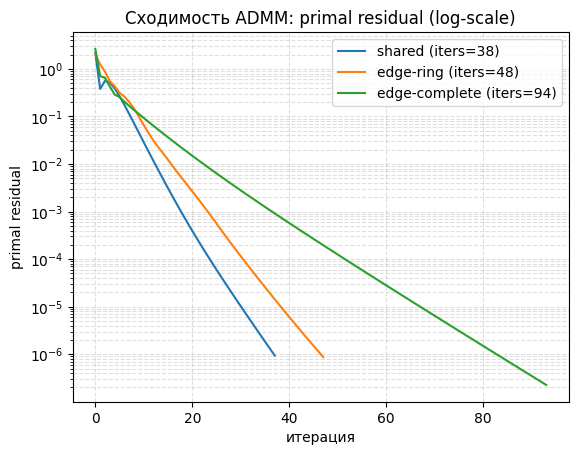

In [10]:
def plot_primal(histories, labels, title):
    plt.figure()
    for h, lab in zip(histories, labels):
        plt.plot(h["r_primal"], label=lab)
    plt.yscale("log")
    plt.xlabel("итерация")
    plt.ylabel("primal residual")
    plt.title(title)
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.show()

plot_primal(
    histories=[hist_shared, hist_edge_ring, hist_edge_complete],
    labels=[
        f"shared (iters={hist_shared['iters']})",
        f"edge-ring (iters={hist_edge_ring['iters']})",
        f"edge-complete (iters={hist_edge_complete['iters']})",
    ],
    title="Сходимость ADMM: primal residual (log-scale)"
)


In [11]:
def iters_to_eps(r, eps=1e-6):
    idx = np.where(r <= eps)[0]
    return int(idx[0] + 1) if len(idx) else None

eps = 1e-6

rows = [
    ("shared", iters_to_eps(hist_shared["r_primal"], eps), hist_shared["iters"], hist_shared["r_primal"][-1]),
    ("edge-ring", iters_to_eps(hist_edge_ring["r_primal"], eps), hist_edge_ring["iters"], hist_edge_ring["r_primal"][-1]),
    ("edge-complete", iters_to_eps(hist_edge_complete["r_primal"], eps), hist_edge_complete["iters"], hist_edge_complete["r_primal"][-1]),
]

print(f"eps = {eps}")
print("method           iters_to_eps   total_iters   final_rp")
for name, k_eps, k_tot, rp_fin in rows:
    print(f"{name:14s} {str(k_eps):12s} {k_tot:11d} {rp_fin:.3e}")


eps = 1e-06
method           iters_to_eps   total_iters   final_rp
shared         38                    38 9.374e-07
edge-ring      48                    48 8.713e-07
edge-complete  84                    94 2.260e-07


In [13]:

rhos = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
eps = 1e-6

def iters_to_eps(r, eps=1e-6):
    idx = np.where(r <= eps)[0]
    return int(idx[0] + 1) if len(idx) else None

print("rho     shared   ring   complete")

for rv in rhos:
    hs = shared_admm(X, y, rho=rv, gamma=gamma, max_iter=max_iter, tol=tol)
    hr = edge_admm(X, y, edges_ring, rho=rv, max_iter=max_iter, tol=tol)
    hc = edge_admm(X, y, edges_complete, rho=rv, max_iter=max_iter, tol=tol)

    ks = iters_to_eps(hs["r_primal"], eps)
    kr = iters_to_eps(hr["r_primal"], eps)
    kc = iters_to_eps(hc["r_primal"], eps)

    print(f"{rv:<6} {str(ks):>6} {str(kr):>6} {str(kc):>9}")


rho     shared   ring   complete
0.05     None   None        63
0.1      None   None        40
0.2       133    190        28
0.5        61     87        50
1.0        38     48        84
2.0        42     63       144
5.0        85    114      None
10.0      145    163      None


### Чувствительность к параметру rho

Эксперимент показывает, что оптимальный параметр ρ
существенно зависит от формы записи задачи.

- Shared-variable формулировка наиболее устойчива при ρ ≈ 1.
- Edge (ring) также работает лучше при ρ ≈ 1.
- Edge (complete) требует существенно меньшего ρ (≈ 0.2).

При слишком малом или слишком большом ρ
некоторые формулировки вообще не достигают заданной точности.

Это означает, что даже выбор гиперпараметра ADMM
зависит от структуры матрицы ограничений.


### Вывод по эксперименту

На toy-задаче "mixture of local and global models" наблюдаем,
что число итераций ADMM заметно зависит от формы записи задачи:

- shared-variable (звезда) сходится быстрее;
- edge-формулировка на кольце медленнее;
- edge-формулировка на полном графе в этой реализации оказалась ещё медленнее.

Это согласуется с гипотезой: хотя задачи эквивалентны,
ADMM чувствителен к структуре ограничений (матрице A),
которая меняется при переформулировке.


## 7. Результаты

Анализируем:

- primal residual
- dual residual
- число итераций до заданной точности
- графики сходимости (log-scale)


## 8. Обсуждение

1. Сохраняется ли зависимость скорости сходимости от формы записи?
2. Усиливается ли эффект по сравнению с HFL?
3. Какие структурные особенности задачи на это влияют?


### Интерпретация результатов

Несмотря на математическую эквивалентность формулировок,
ADMM демонстрирует различную скорость сходимости.

Причина — различие в структуре матрицы ограничений A.

#### 1. Shared-variable (звезда)

Матрица A соответствует "звёздной" структуре.
Спектр системы определяется числом агентов N,
а глобальный шаг фактически является усреднением.

Обновление w_0 решается в явном виде,
и система хорошо обусловлена.

→ Быстрая сходимость.

---

#### 2. Edge (кольцо)

Матрица ограничений — инцидентная матрица кольца.
ADMM фактически работает с лапласианом графа.

Собственные значения лапласиана кольца
имеют маленький спектральный зазор.

→ Сходимость замедляется.

---

#### 3. Edge (полный граф)

Полный граф имеет большой спектральный зазор,
однако:

- число ограничений существенно больше,
- размер двойственной части растёт,
- система для w_i включает множитель степени вершины,
- обусловленность ухудшается при фиксированном ρ.

В данной реализации увеличение плотности графа
привело к ухудшению динамики ADMM.

---

### Главный вывод

Скорость сходимости ADMM определяется не только задачей,
но и способом её записи.

Эквивалентные оптимизационные задачи могут
иметь существенно различную динамику при использовании ADMM,
поскольку алгоритм чувствителен к спектральным свойствам
матрицы ограничений.

Это подтверждает гипотезу статьи о зависимости
алгоритмической сложности от формулировки.
